# Tutorial - Ligand handling

First, let's verify that `Boltz-tools` is installed correctly by running:

In [8]:
!boltz-lab --version

boltz-lab 0.0.0-dev


If the installation was successful, this command will display the installed version number of `Boltz-tools`.

If you encounter any errors, refer to the installation guide in the `README.md` file to troubleshoot and complete the setup.

> **Note:**  
> - When running these commands in a regular command-line interface (CLI), remove the `!` at the beginning of the command.
> - If you're copying commands from a Jupyter Notebook that use backslashes (`\`) to split long commands across multiple lines, remove the backslashes and write the command on a single line in the CLI.

# System handling

# TODO: pocket contraints
- lepatinib (back pocket)
- add force


# TODO: bond constraints
- hinge region interactions between specific atoms
- add force

### Covalent bonds
Covalent: Case of Afatinib

First, we need to add an CCD entry of Afatinib to the Boltz cache:

In [9]:
from rdkit import Chem
from rdkit.Chem import AllChem
from boltz_tools.helpers.conformers import mol_to_ccd

smiles = "CN(C)C/C=C/C(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=C(C=C3)F)Cl)O[C@H]4CCOC4"    # Afatinib

mol = Chem.MolFromSmiles(smiles)
   
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, AllChem.ETKDG())
AllChem.UFFOptimizeMolecule(mol)
mol_3d = mol

mol_to_ccd("afati", mol_3d, './cache/.boltz') 

We visualize our molecule to make sure we select the correct atom for covalent binding. Here C5 is the atom which will support the covalent bond.

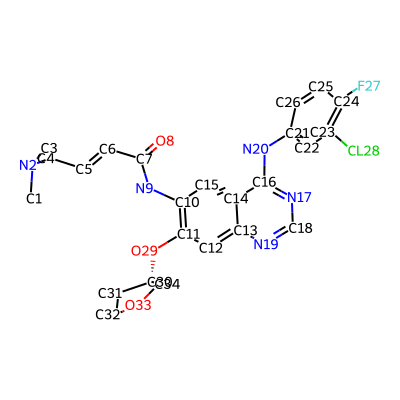

In [10]:
import pickle
from rdkit.Chem import Draw

# Load molecule from pickle
with open("./cache/.boltz/mols/afati.pkl", "rb") as f:
    mol = pickle.load(f)

for atom in mol.GetAtoms():
        atom.SetProp("atomLabel", atom.GetProp("name"))

Draw.MolToImage(
    mol, 
    size=(400,400), 
    kekulize=True, 
    wedgeBonds=True, 
    includeAtomNumbers=True
)

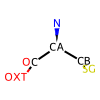

In [11]:
import pickle
from rdkit.Chem import Draw

# Load molecule from pickle
with open("./cache/.boltz/mols/CYS.pkl", "rb") as f:
    mol = pickle.load(f)

for atom in mol.GetAtoms():
        atom.SetProp("atomLabel", atom.GetProp("name"))

Draw.MolToImage(
    mol, 
    size=(100,100)
)

In [12]:
with open('../examples/system_covalent.yaml', 'r') as file:
    content = file.read()

print(content)

sequences:
  - protein:
      id: A
      sequence: FKKIKVLGSGAFGTVYKGLWIPEGEKVKIPVAIKELREATSPKANKEILDEAYVMASVDNPHVCRLLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQIAKGMNYLEDRRLVHRDLAARNVLVKTPQHVKITDFGLAKLLGAEEKEYHAEGGKVPIKWMALESILHRIYTHQSDVWSYGVTVWELMTFGSKPYDGIPASEISSILEKGERLPQPPICTIDVYMIMVKCWMIDADSRPKFRELIIEFSKMARDPQRYL
  - ligand:
      id: B
      ccd: afati
constraints:
  - bond:
      atom1: [A, 86, SG]
      atom2: [B, 1, C5]



In [13]:
!boltz-lab predict \
        -w ./tmp/tutorial_covalent \
        -s ../examples/system_covalent.yaml \
        -b ../examples/options.yaml

INFO:boltz-lab.helpers:Key not found in system: msa
INFO:boltz-lab.screening.Screen:Running: boltz predict ../examples/system_covalent.yaml --out_dir ./tmp/tutorial_covalent --use_msa_server --cache ./cache/.boltz --use_potentials
MSA server enabled: https://api.colabfold.com
MSA server authentication: no credentials provided
Checking input data.
All inputs are already processed.
Processing 0 inputs with 0 threads.
0it [00:00, ?it/s]
Found some existing predictions (1), skipping and running only the missing ones, if any. If you wish to override these existing predictions, please set the --override flag.
/home/remco/.conda/envs/boltz-lab/lib/python3.12/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.1 /home/remco/.conda/envs/boltz-lab/bin/boltz pre ...
Using bfloat16 Automatic Mixed Precision

# Input file options
# TODO: Show pridictions based on SMILES or SDF are different
# TODO: Stereoisomer handling with SDF